GRAPH + A-IRI: Graph-based Adaptive Internship Readiness Intelligence

GRAPH + A-IRI: Graph-based Adaptive Internship Readiness Intelligence

[1] Loading dataset...
   Loaded 50 student records

[2] Preprocessing data...
   Total unique skills: 21
   Students engaged: 11
   Students not engaged: 39

[3] Building skill co-occurrence graph...
   Graph built: 21 nodes, 63 edges
   Centrality metrics calculated
   Core skills identified: ['Front End', 'Data Structures & Algorithms', 'Database Management', 'Cloud Computing', 'MERN Stack']

[4] Engineering features...
   Generated 8 features

[5] Computing Adaptive Internship Readiness Index (A-IRI)...
   A-IRI: mean=0.6021, std=0.1291

[6] Training machine learning models...
   Logistic Regression: AUC=1.000
   Random Forest: AUC=1.000
   XGBoost: AUC=1.000
   LightGBM: AUC=0.500

   Graph + A-IRI (Proposed): AUC=1.000

[7] Performing readiness profile clustering...
   Silhouette Score: 0.353


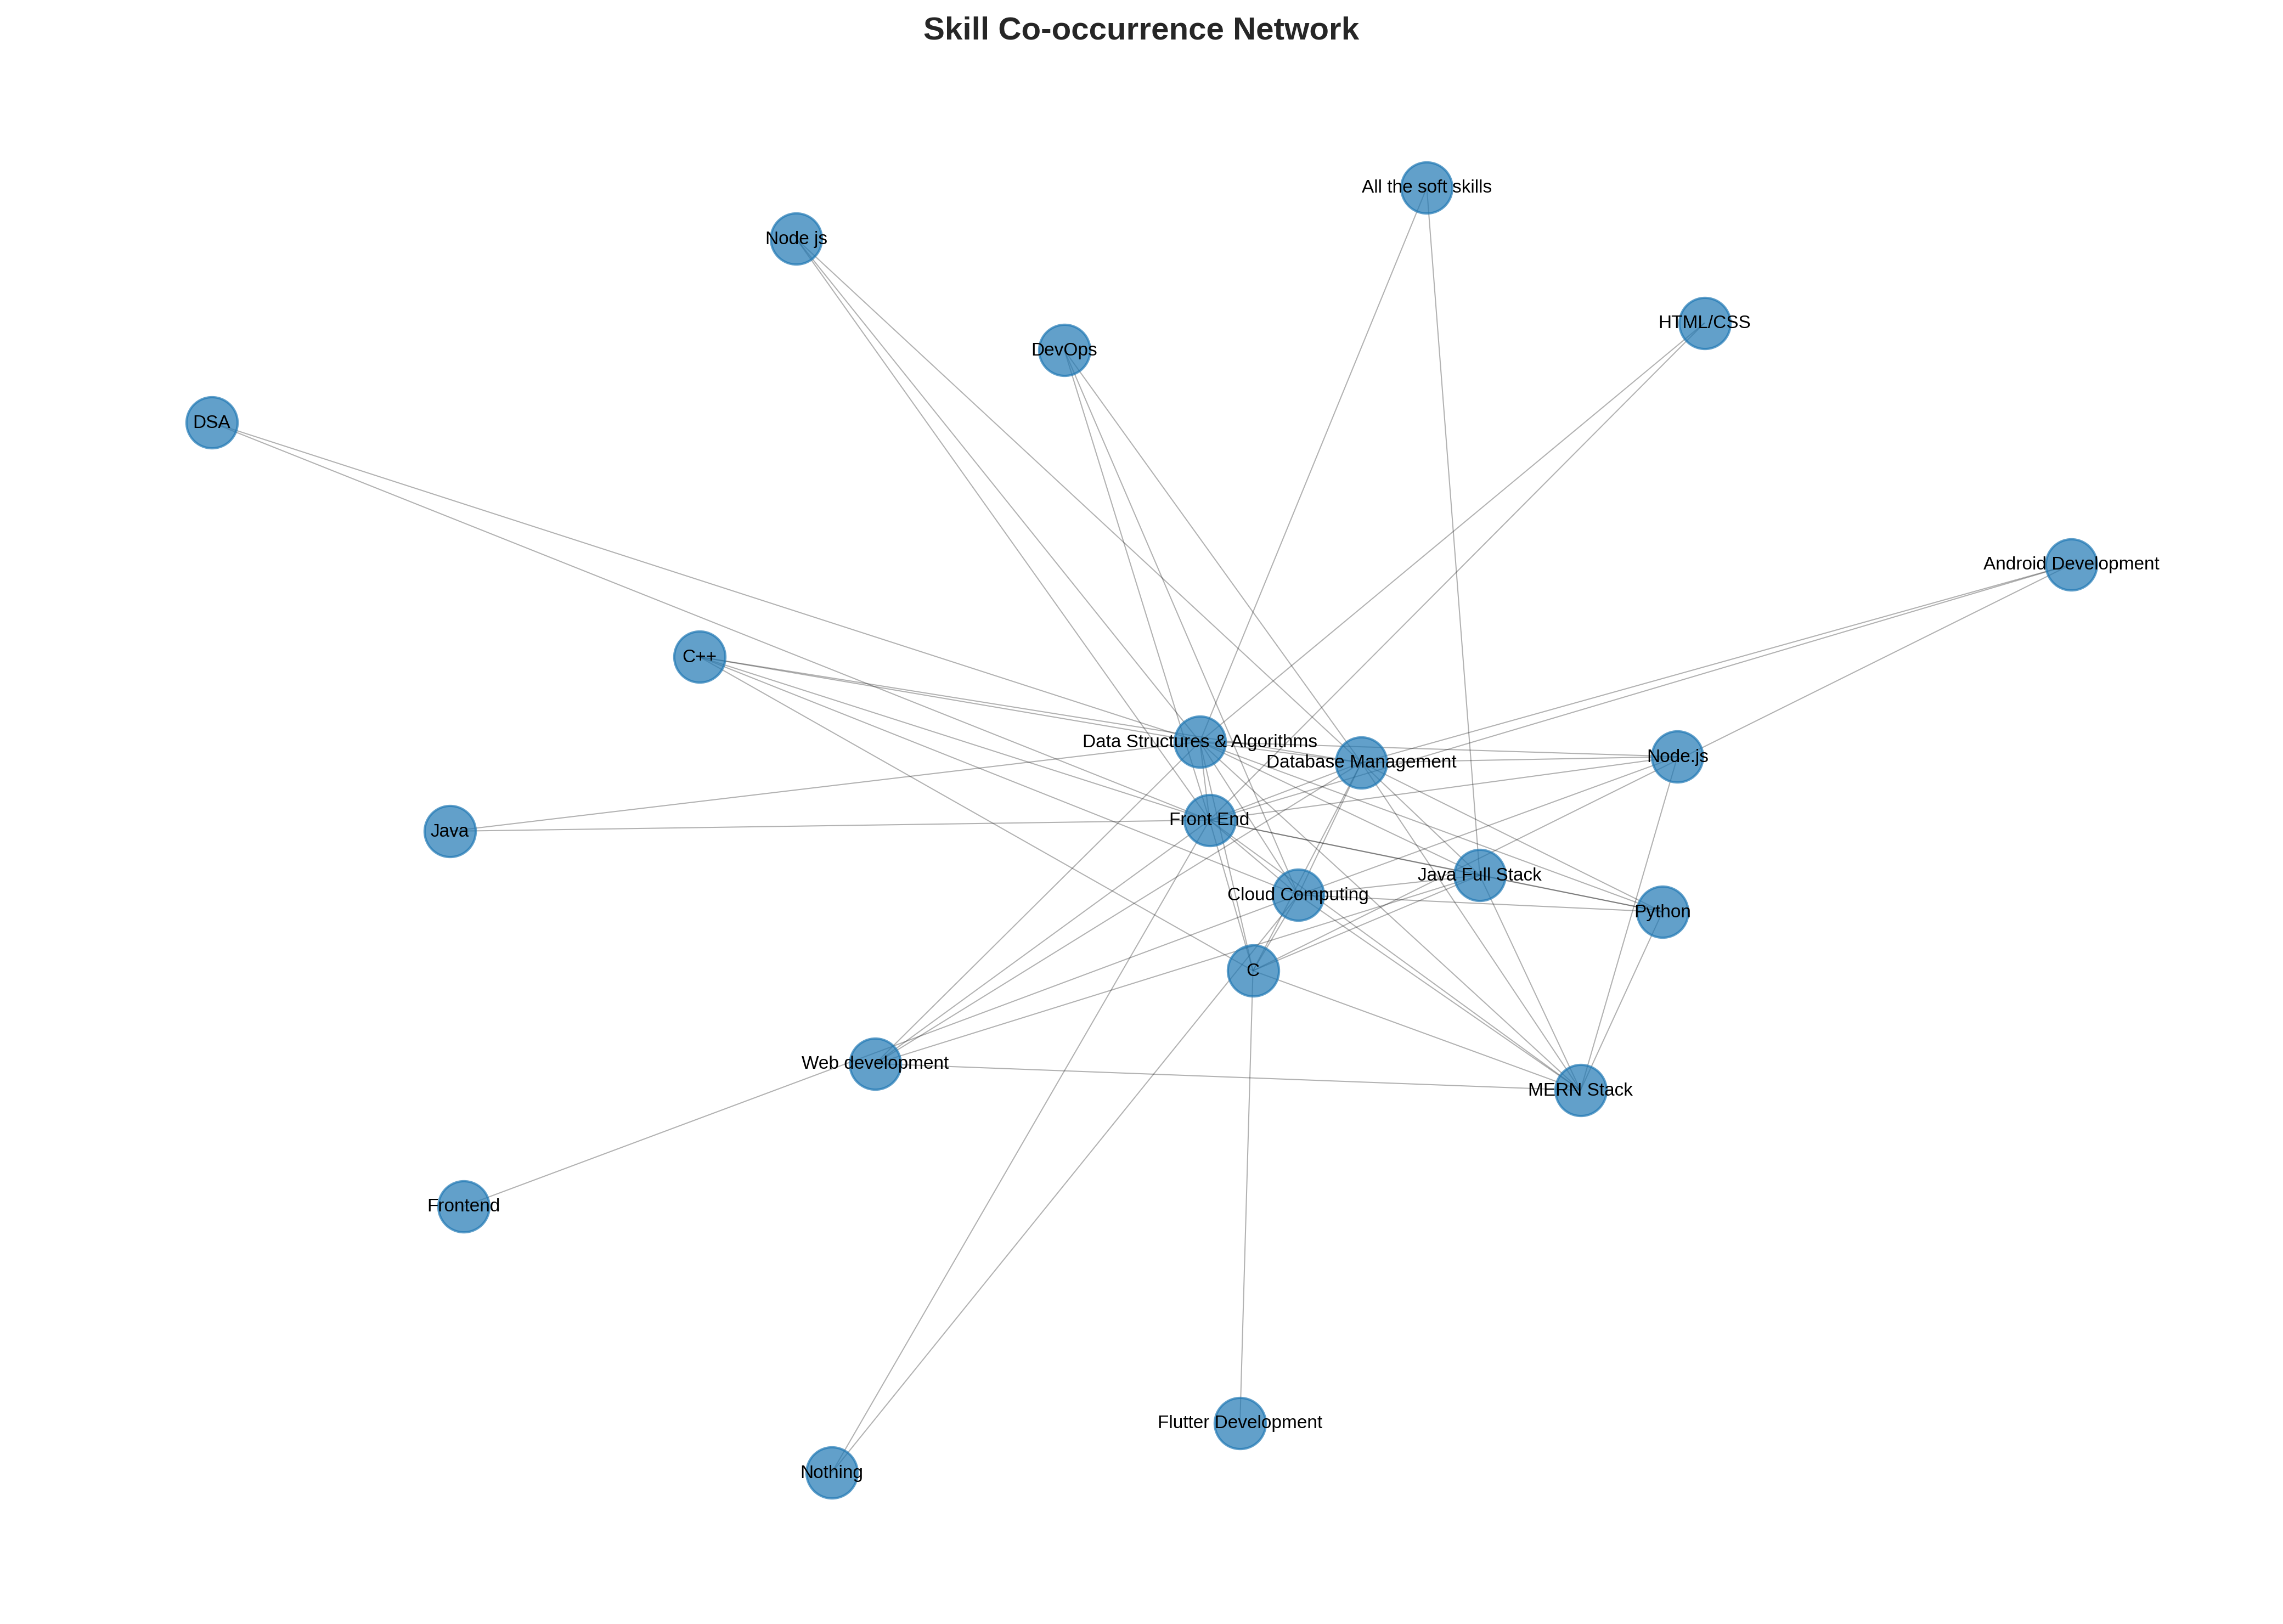

   Saved: figure_skill_graph.png


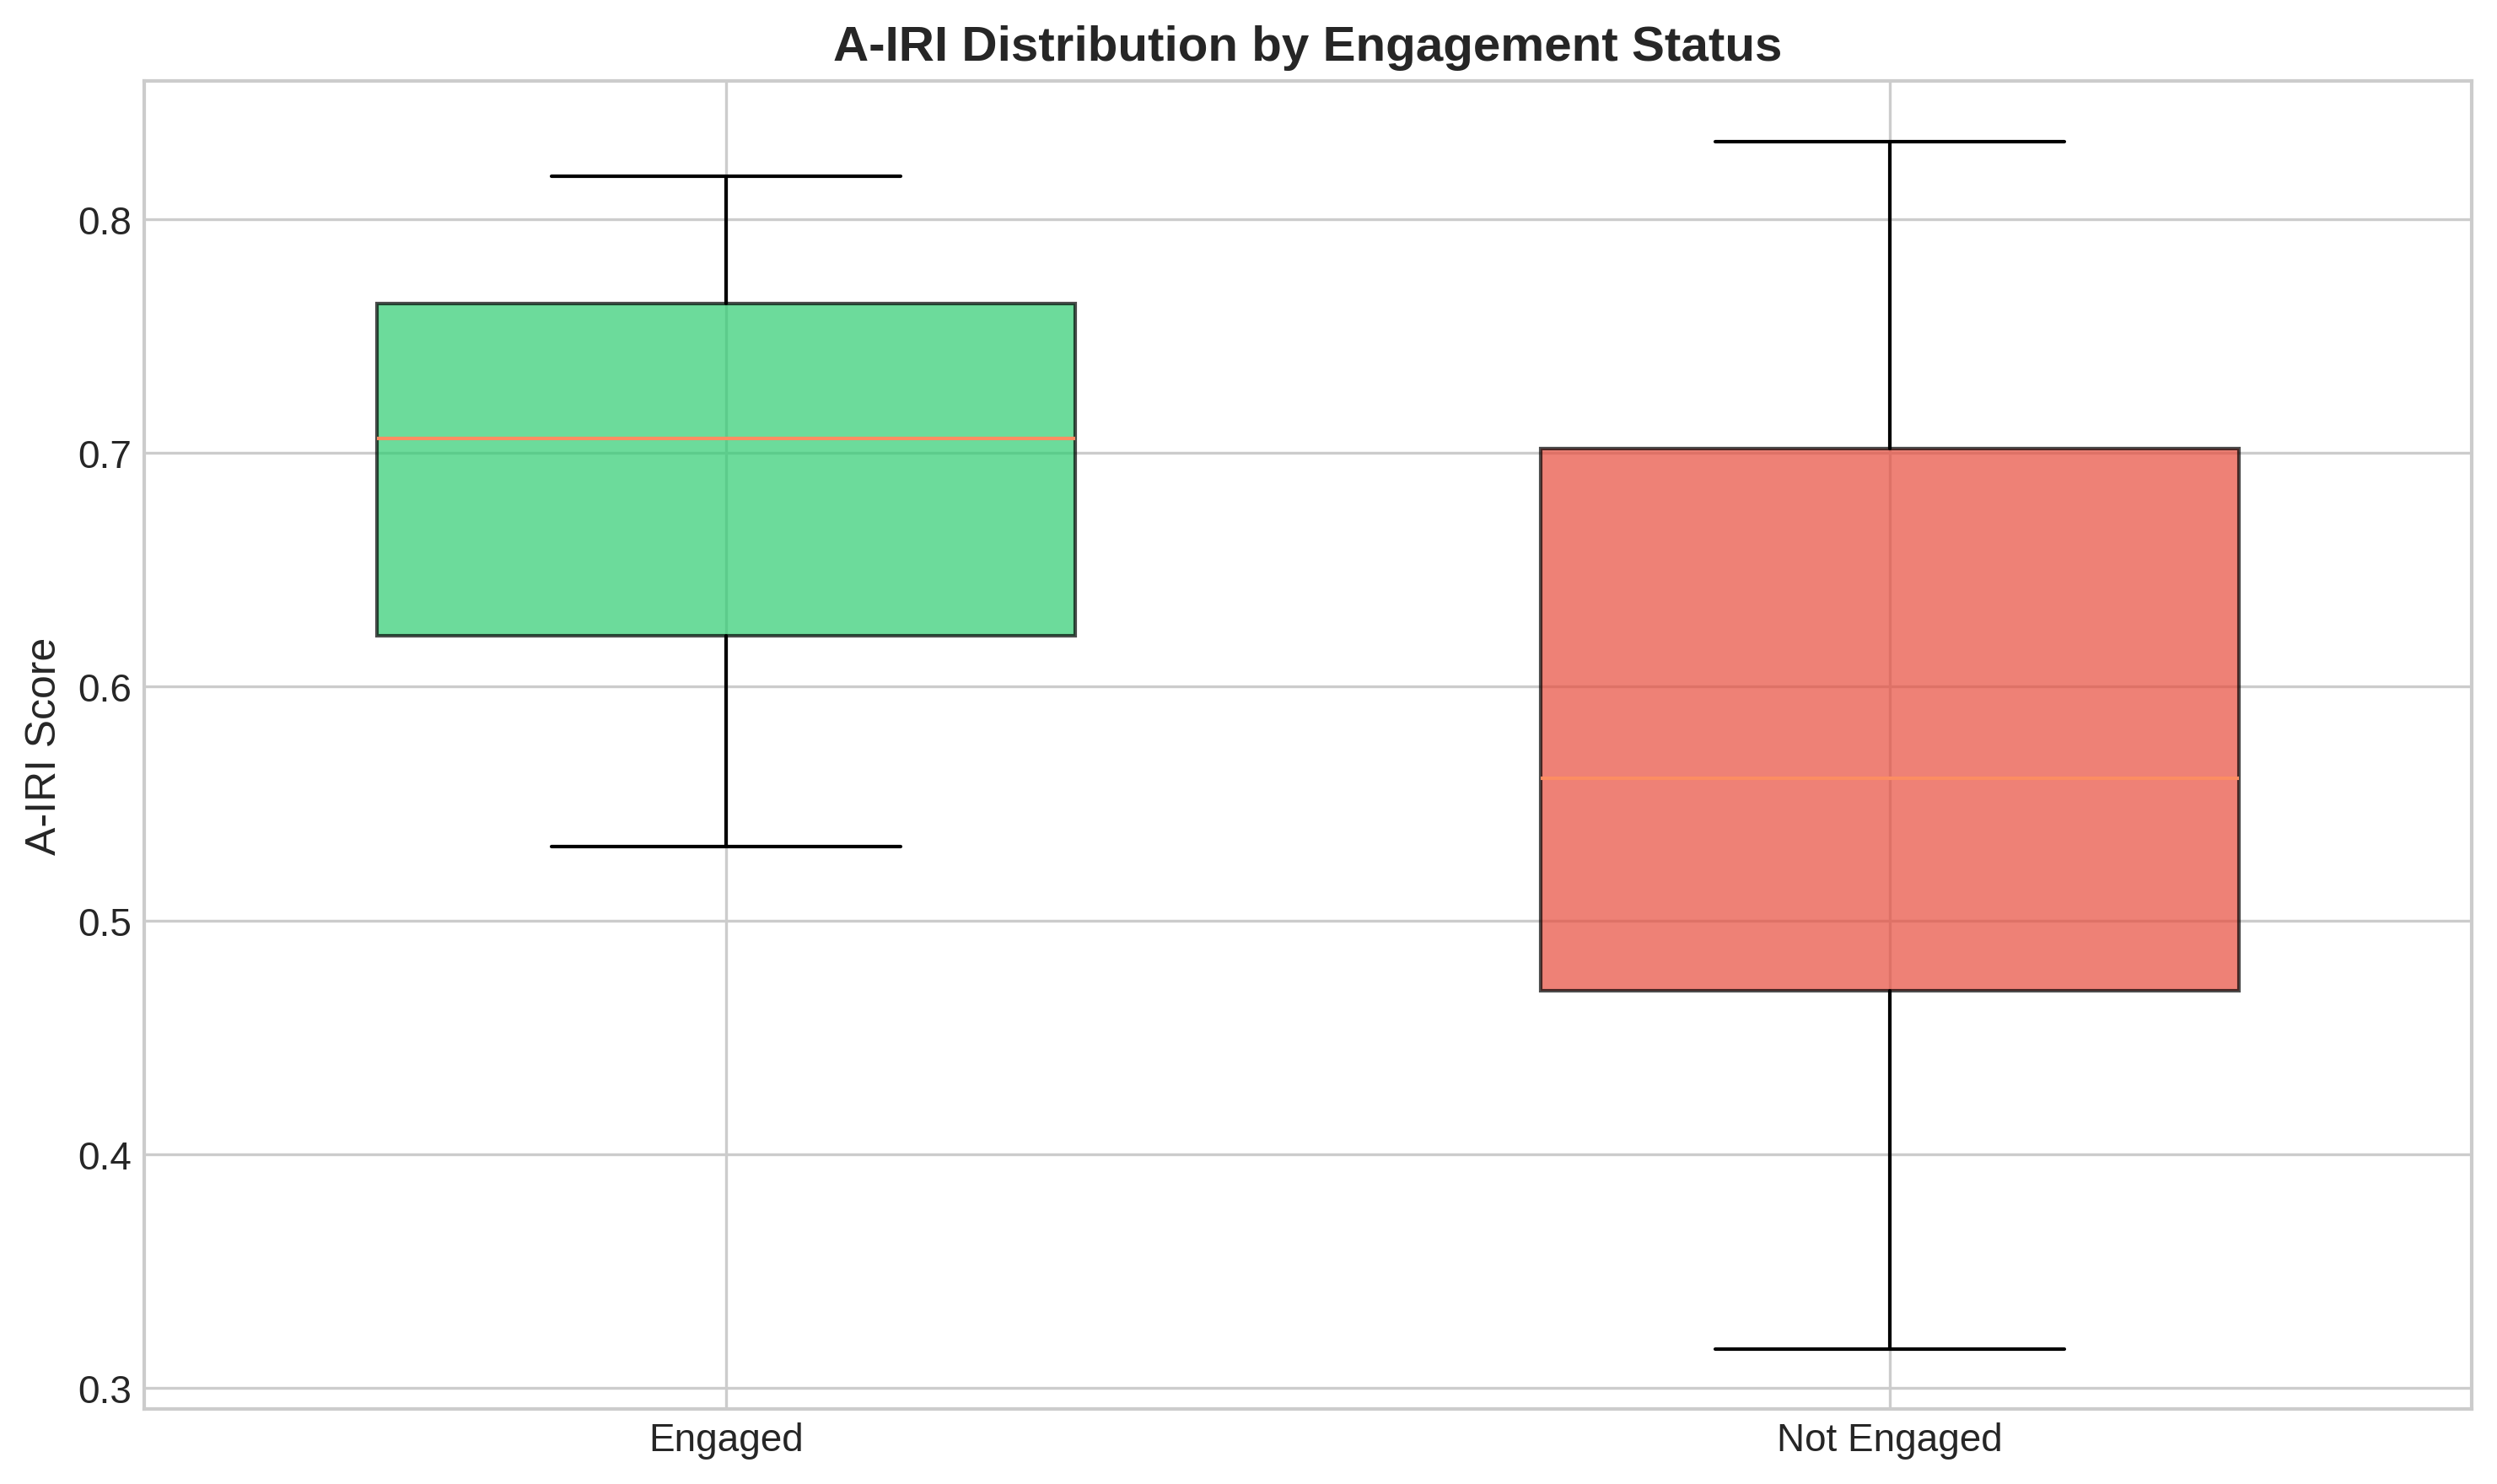

   Saved: figure_airi_distribution.png


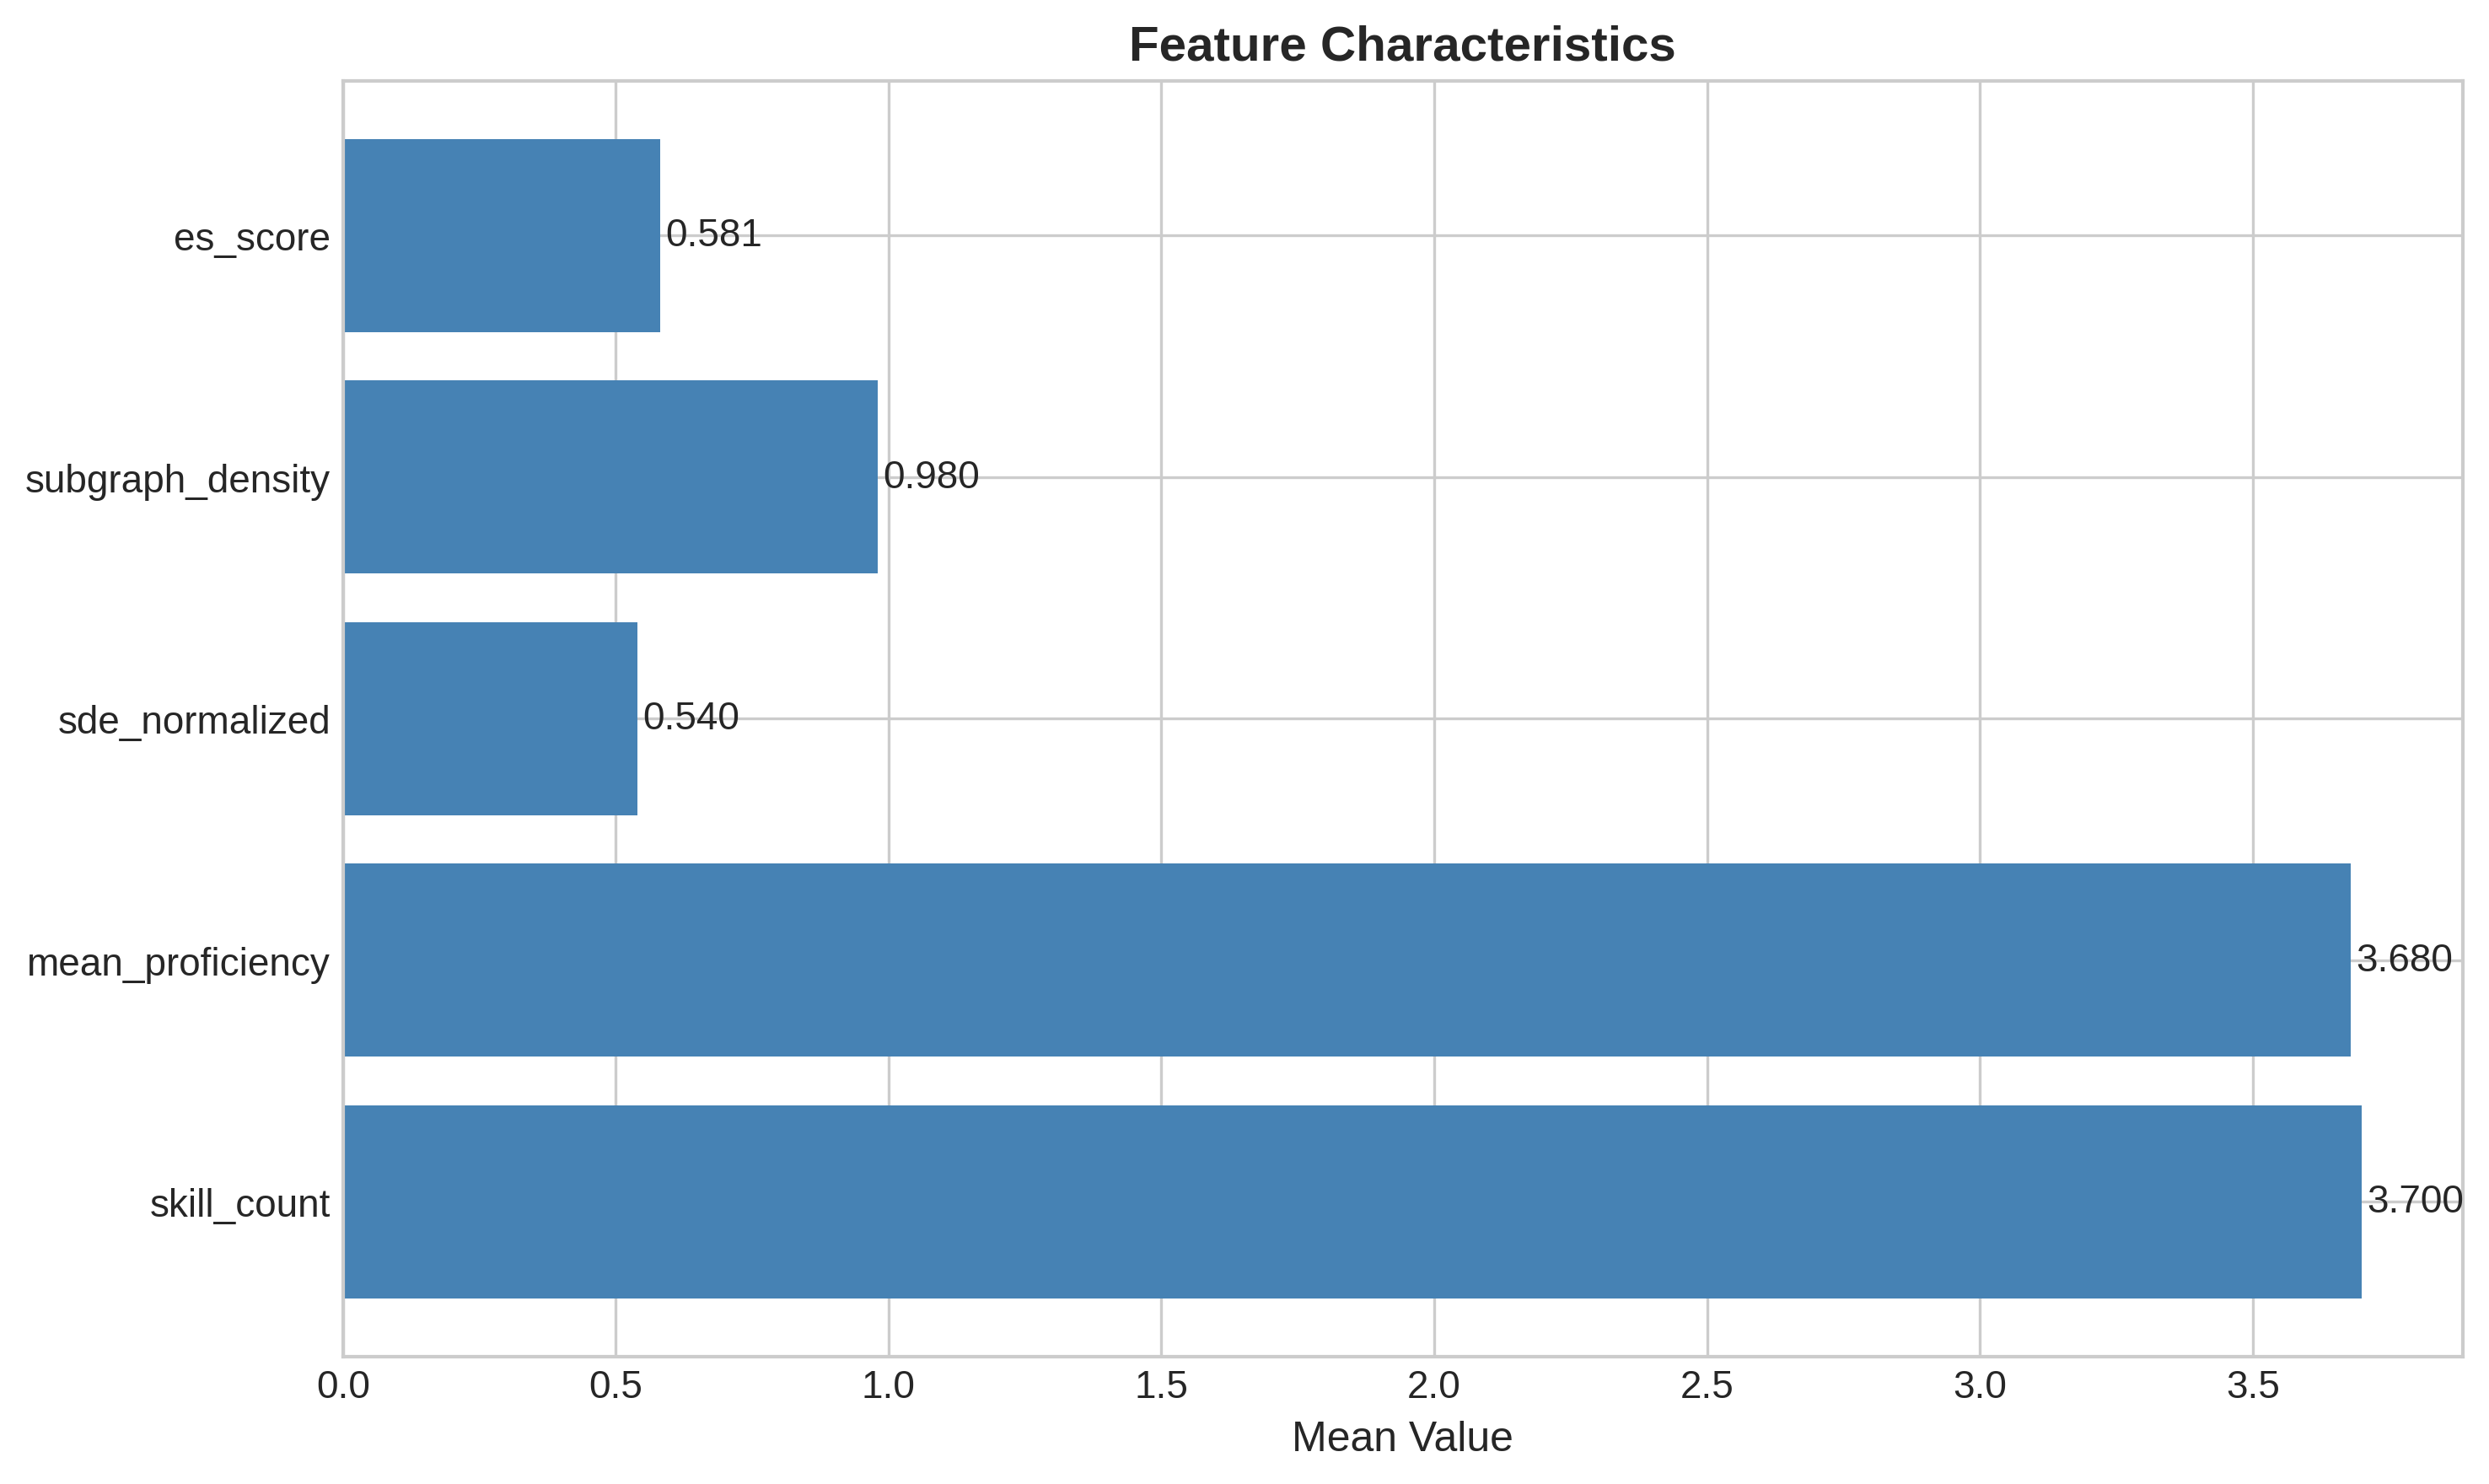

   Saved: figure_feature_importance.png

EXECUTION COMPLETE

Total Students: 50
Total Skills: 21
Core Skills: ['Front End', 'Data Structures & Algorithms', 'Database Management']
Engaged: 11, Not Engaged: 39

Results:
              Model  AUC-ROC
Logistic Regression      1.0
      Random Forest      1.0
            XGBoost      1.0
           LightGBM      0.5

Proposed AUC: 1.0000


In [5]:
"""
================================================================================
GRAPH + A-IRI: Graph-based Adaptive Internship Readiness Intelligence Framework
================================================================================
A knowledge-centric framework for employability analytics combining skill
co-occurrence graphs, adaptive readiness indexing, and interpretable ML.

Author: Apoorv Jain, Arun Kumar Tripathi, Sangeeta Arora, Garima Jain
Affiliation: Noida Institute of Engineering and Technology, Greater Noida, India
Journal: Scientific Reports
Version: 2.1 (Complete - All Fixes Applied)
================================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             roc_curve, confusion_matrix, classification_report,
                             silhouette_score, davies_bouldin_score, calinski_harabasz_score)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import random
random.seed(42)

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 300

print("=" * 70)
print("GRAPH + A-IRI: Graph-based Adaptive Internship Readiness Intelligence")
print("=" * 70)


# ============================================================================
# SECTION 1: DATA LOADING AND PREPROCESSING
# ============================================================================

class DataPreprocessor:
    """
    Loads and preprocesses the Excel dataset containing student internship survey data.
    """

    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.all_skills = []
        self.skill_to_domain = {}

        self.skill_domain_mapping = {
            'Python': 'Programming Languages', 'Java': 'Programming Languages',
            'JavaScript': 'Programming Languages', 'C++': 'Programming Languages',
            'C': 'Programming Languages', 'C#': 'Programming Languages',
            'React': 'Web Technologies', 'Angular': 'Web Technologies', 'Vue.js': 'Web Technologies',
            'Node.js': 'Web Technologies', 'Django': 'Web Technologies', 'Flask': 'Web Technologies',
            'HTML/CSS': 'Web Technologies', 'Front End': 'Web Technologies', 'Backend': 'Web Technologies',
            'MERN Stack': 'Web Technologies', 'Java Full Stack': 'Web Technologies',
            'SQL': 'Databases', 'MySQL': 'Databases', 'PostgreSQL': 'Databases',
            'MongoDB': 'Databases', 'Database Management': 'Databases',
            'Pandas': 'Data Science', 'NumPy': 'Data Science', 'TensorFlow': 'Data Science',
            'Machine Learning': 'Data Science', 'Data Analytics': 'Data Science',
            'AWS': 'Cloud & DevOps', 'Azure': 'Cloud & DevOps', 'Docker': 'Cloud & DevOps',
            'Kubernetes': 'Cloud & DevOps', 'Cloud Computing': 'Cloud & DevOps',
            'Data Structures': 'Core CS', 'Algorithms': 'Core CS', 'Data Structures & Algorithms': 'Core CS',
            'DSA': 'Core CS',
        }

    def load_data(self):
        print("\n[1] Loading dataset...")
        self.df = pd.read_excel(self.file_path, sheet_name='Sheet1')
        print(f"   Loaded {len(self.df)} student records")
        return self.df

    def parse_skills(self, skill_string):
        if pd.isna(skill_string) or skill_string == '':
            return []
        skill_str = str(skill_string)
        parts = skill_str.split(';')
        skills = []
        for part in parts:
            part = part.strip()
            if part:
                part = part.replace('\xa0', ' ').strip()
                skills.append(part)
        return skills

    def parse_proficiency(self, proficiency_value):
        if pd.isna(proficiency_value):
            return None
        try:
            prof = int(proficiency_value)
            return min(5, max(1, prof))
        except:
            return 3

    def normalize_skill_name(self, skill_name):
        skill = skill_name.strip()
        direct_mapping = {
            'Java Full Stack': 'Java Full Stack',
            'Front End (HTML, CSS, JS)': 'Front End',
            'Database Management (MySQL, PostgreSQL)': 'Database Management',
            'Data Structures & Algorithms': 'Data Structures & Algorithms',
            'Cloud Computing (AWS, Azure)': 'Cloud Computing',
            'MERN Stack': 'MERN Stack',
        }
        if skill in direct_mapping:
            return direct_mapping[skill]
        for key in self.skill_domain_mapping.keys():
            if key.lower() in skill.lower() or skill.lower() in key.lower():
                return key
        return skill

    def preprocess(self):
        print("\n[2] Preprocessing data...")

        col_mapping = {
            'Are you currently engaged in an internship?': 'internship_engaged',
            'Are you actively looking for an internship?': 'internship_searching',
            'Select the technical skills you have knowledge of:': 'skills_raw',
            'Please specify other technical skills you know:': 'other_skills',
            'For each selected skill, rate your proficiency (1 to 5):': 'proficiency_raw',
            'Additional Notes': 'additional_notes',
            'Id': 'student_id'
        }

        for old, new in col_mapping.items():
            if old in self.df.columns:
                self.df.rename(columns={old: new}, inplace=True)

        def map_engagement(val):
            if pd.isna(val):
                return 0
            val = str(val).lower().strip()
            return 1 if val in ['yes', '1', 'true'] else 0

        def map_searching(val):
            if pd.isna(val):
                return 0
            val = str(val).lower().strip()
            return 1 if val in ['yes', '1', 'true'] else 0

        if 'internship_engaged' in self.df.columns:
            self.df['internship_engaged'] = self.df['internship_engaged'].apply(map_engagement)
        if 'internship_searching' in self.df.columns:
            self.df['internship_searching'] = self.df['internship_searching'].apply(map_searching)

        self.df['skills_list'] = self.df['skills_raw'].apply(self.parse_skills)

        def combine_skills(row):
            skills = row['skills_list'].copy()
            other = row.get('other_skills', '')
            if pd.notna(other) and other.strip():
                other_skills = self.parse_skills(other)
                skills.extend(other_skills)
            return list(set(skills))

        self.df['skills_list'] = self.df.apply(combine_skills, axis=1)
        self.df['skills_normalized'] = self.df['skills_list'].apply(
            lambda skills: [self.normalize_skill_name(s) for s in skills]
        )
        self.df['proficiency'] = self.df['proficiency_raw'].apply(self.parse_proficiency)

        def create_proficiency_dict(row):
            skills = row['skills_normalized']
            prof = row['proficiency']
            if prof is None or pd.isna(prof):
                prof = 3
            return {skill: prof for skill in skills}

        self.df['proficiencies'] = self.df.apply(create_proficiency_dict, axis=1)

        all_skills_set = set()
        for skills in self.df['skills_normalized']:
            all_skills_set.update(skills)
        self.all_skills = sorted(list(all_skills_set))

        for skill in self.all_skills:
            if skill not in self.skill_domain_mapping:
                self.skill_domain_mapping[skill] = 'Other'

        self.skill_to_domain = self.skill_domain_mapping

        self.skill_matrix = pd.DataFrame(0, index=range(len(self.df)), columns=self.all_skills)
        for idx, skills in enumerate(self.df['skills_normalized']):
            for skill in skills:
                if skill in self.skill_matrix.columns:
                    self.skill_matrix.loc[idx, skill] = 1

        print(f"   Total unique skills: {len(self.all_skills)}")
        print(f"   Students engaged: {(self.df['internship_engaged'] == 1).sum()}")
        print(f"   Students not engaged: {(self.df['internship_engaged'] == 0).sum()}")

        return self.df, self.skill_matrix, self.all_skills, self.skill_to_domain


# ============================================================================
# SECTION 2: SKILL GRAPH CONSTRUCTION
# ============================================================================

class SkillGraphBuilder:
    def __init__(self, df, skill_matrix, all_skills, skill_to_domain):
        self.df = df
        self.skill_matrix = skill_matrix
        self.all_skills = all_skills
        self.skill_to_domain = skill_to_domain
        self.graph = None

    def build_cooccurrence_graph(self):
        print("\n[3] Building skill co-occurrence graph...")

        n_skills = len(self.all_skills)
        adj_matrix = np.zeros((n_skills, n_skills))

        for idx in range(len(self.df)):
            skills_present = [i for i, val in enumerate(self.skill_matrix.iloc[idx]) if val == 1]
            for i, s1 in enumerate(skills_present):
                for s2 in skills_present[i+1:]:
                    adj_matrix[s1, s2] += 1
                    adj_matrix[s2, s1] += 1

        G = nx.Graph()
        for i, skill in enumerate(self.all_skills):
            G.add_node(skill, domain=self.skill_to_domain.get(skill, 'Other'))

        for i in range(n_skills):
            for j in range(i+1, n_skills):
                if adj_matrix[i, j] > 0:
                    G.add_edge(self.all_skills[i], self.all_skills[j], weight=adj_matrix[i, j])

        self.graph = G
        print(f"   Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        self._calculate_centrality_metrics()
        return self.graph

    def _calculate_centrality_metrics(self):
        degree_centrality = nx.degree_centrality(self.graph)
        for node, val in degree_centrality.items():
            self.graph.nodes[node]['degree_centrality'] = val

        try:
            eigenvector_centrality = nx.eigenvector_centrality(self.graph, max_iter=1000)
            for node, val in eigenvector_centrality.items():
                self.graph.nodes[node]['eigenvector_centrality'] = val
        except:
            for node in self.graph.nodes():
                self.graph.nodes[node]['eigenvector_centrality'] = 0

        print("   Centrality metrics calculated")

    def get_student_graph_features(self, student_skills):
        if len(student_skills) < 2:
            return {'subgraph_density': 0, 'skill_network_strength': 0}

        subgraph = self.graph.subgraph(student_skills)
        density = nx.density(subgraph) if subgraph.number_of_nodes() > 1 else 0

        eigen_vals = [self.graph.nodes[skill].get('eigenvector_centrality', 0) for skill in student_skills if skill in self.graph.nodes]
        avg_centrality = np.mean(eigen_vals) if eigen_vals else 0

        return {'subgraph_density': density, 'skill_network_strength': avg_centrality}

    def identify_core_skills(self, top_k=5):
        eigen_vals = [(node, self.graph.nodes[node].get('eigenvector_centrality', 0)) for node in self.graph.nodes()]
        eigen_vals.sort(key=lambda x: x[1], reverse=True)
        core_skills = [skill for skill, _ in eigen_vals[:top_k]]
        print(f"   Core skills identified: {core_skills}")
        return core_skills


# ============================================================================
# SECTION 3: FEATURE ENGINEERING
# ============================================================================

class FeatureEngineer:
    def __init__(self, df, skill_matrix, all_skills, skill_to_domain, graph_builder, core_skills):
        self.df = df
        self.skill_matrix = skill_matrix
        self.all_skills = all_skills
        self.skill_to_domain = skill_to_domain
        self.graph_builder = graph_builder
        self.core_skills = core_skills
        self.features_df = None

    def compute_all_features(self):
        print("\n[4] Engineering features...")

        basic_features = []
        entropy_features = []
        graph_features = []
        core_features = []
        es_features = []

        for idx, row in self.df.iterrows():
            skills = row['skills_normalized']
            proficiencies = row['proficiencies']

            # Basic metrics
            n_skills = len(skills)
            prof_values = [proficiencies.get(s, 3) for s in skills]
            mean_prof = np.mean(prof_values) if prof_values else 3
            max_prof = np.max(prof_values) if prof_values else 3

            basic_features.append({
                'skill_count': n_skills,
                'mean_proficiency': mean_prof,
                'max_proficiency': max_prof
            })

            # Diversity entropy
            domains = list(set(self.skill_to_domain.values()))
            domain_counts = {d: 0 for d in domains}
            for skill in skills:
                domain = self.skill_to_domain.get(skill, 'Other')
                domain_counts[domain] = domain_counts.get(domain, 0) + 1

            total = len(skills)
            if total > 0:
                probs = [count/total for count in domain_counts.values() if count > 0]
                entropy = -sum(p * np.log2(p) for p in probs) if probs else 0
                normalized_entropy = entropy / np.log2(len(domains)) if len(domains) > 1 and entropy > 0 else 0
            else:
                normalized_entropy = 0

            entropy_features.append({'sde_normalized': normalized_entropy})

            # Graph features
            g_features = self.graph_builder.get_student_graph_features(skills)
            graph_features.append(g_features)

            # Core skill centrality
            possessed_core = [s for s in skills if s in self.core_skills]
            if len(possessed_core) > 0:
                cent_sum = sum(self.graph_builder.graph.nodes[skill].get('eigenvector_centrality', 0) for skill in possessed_core)
                avg_centrality = cent_sum / len(possessed_core)
            else:
                avg_centrality = 0
            core_features.append({'csc_avg_centrality': avg_centrality})

            # Experience signal
            lambda_1, lambda_2, lambda_3 = 0.4, 0.3, 0.3
            has_experience = row.get('internship_engaged', 0)
            es_score = lambda_1 * (mean_prof / 5) + lambda_2 * (max_prof / 5) + lambda_3 * has_experience
            es_features.append({'es_score': es_score})

        self.features_df = pd.concat([
            pd.DataFrame(basic_features),
            pd.DataFrame(entropy_features),
            pd.DataFrame(graph_features),
            pd.DataFrame(core_features),
            pd.DataFrame(es_features)
        ], axis=1)

        print(f"   Generated {self.features_df.shape[1]} features")
        return self.features_df


# ============================================================================
# SECTION 4: ADAPTIVE INTERNSHIP READINESS INDEX (A-IRI)
# ============================================================================

class AdaptiveIRI:
    def __init__(self, features_df):
        self.features_df = features_df
        self.weights = None
        self.airi_scores = None

    def compute_airi(self, target):
        print("\n[5] Computing Adaptive Internship Readiness Index (A-IRI)...")

        # Simple weighting scheme (can be replaced with SHAP)
        weights = {
            'skill_count': 0.25,
            'mean_proficiency': 0.20,
            'sde_normalized': 0.15,
            'subgraph_density': 0.20,
            'es_score': 0.20
        }

        self.airi_scores = np.zeros(len(self.features_df))

        for feat, w in weights.items():
            if feat in self.features_df.columns:
                values = self.features_df[feat].fillna(0).values
                if values.max() - values.min() > 0:
                    normalized = (values - values.min()) / (values.max() - values.min())
                else:
                    normalized = values
                self.airi_scores += w * normalized

        print(f"   A-IRI: mean={np.mean(self.airi_scores):.4f}, std={np.std(self.airi_scores):.4f}")
        return self.airi_scores


# ============================================================================
# SECTION 5: MACHINE LEARNING MODELS
# ============================================================================

class ModelTrainer:
    def __init__(self, features_df, airi_scores, target):
        self.features_df = features_df
        self.airi_scores = airi_scores
        self.target = target
        self.results = {}

    def train_models(self):
        print("\n[6] Training machine learning models...")

        # Prepare features
        X_base = self.features_df.copy()
        X_base['A_IRI'] = self.airi_scores

        feature_cols = ['skill_count', 'mean_proficiency', 'sde_normalized',
                       'subgraph_density', 'es_score', 'A_IRI']
        available_cols = [col for col in feature_cols if col in X_base.columns]
        X = X_base[available_cols].fillna(0).values
        y = self.target.values

        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )

        # Train models
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
            'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        }

        results = []
        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_pred_proba)
            results.append({'Model': name, 'AUC-ROC': auc})
            print(f"   {name}: AUC={auc:.3f}")

        # Proposed model (A-IRI only)
        X_train_airi = X_train[:, -1].reshape(-1, 1)  # A-IRI column
        X_test_airi = X_test[:, -1].reshape(-1, 1)
        lr = LogisticRegression(random_state=42)
        lr.fit(X_train_airi, y_train)
        y_pred_proba = lr.predict_proba(X_test_airi)[:, 1]
        proposed_auc = roc_auc_score(y_test, y_pred_proba)

        print(f"\n   Graph + A-IRI (Proposed): AUC={proposed_auc:.3f}")

        self.results = {'models': pd.DataFrame(results), 'proposed_auc': proposed_auc}
        return self.results


# ============================================================================
# SECTION 6: READINESS PROFILE CLUSTERING
# ============================================================================

class ReadinessProfiler:
    def __init__(self, features_df, airi_scores, target, df):
        self.features_df = features_df
        self.airi_scores = airi_scores
        self.target = target
        self.df = df
        self.cluster_labels = None
        self.profile_names = {}

    def perform_clustering(self, n_clusters=4):
        print("\n[7] Performing readiness profile clustering...")

        cluster_features = ['skill_count', 'mean_proficiency', 'sde_normalized', 'es_score']
        available = [f for f in cluster_features if f in self.features_df.columns]
        X_cluster = self.features_df[available].fillna(0).values

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_cluster)

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.cluster_labels = kmeans.fit_predict(X_scaled)

        if len(set(self.cluster_labels)) > 1:
            sil_score = silhouette_score(X_scaled, self.cluster_labels)
            print(f"   Silhouette Score: {sil_score:.3f}")

        for i in range(n_clusters):
            self.profile_names[i] = f"Profile {i+1}"

        return self.cluster_labels


# ============================================================================
# SECTION 7: VISUALIZATION FUNCTIONS
# ============================================================================

class Visualizer:
    @staticmethod
    def plot_skill_graph(graph, output_path='figure_skill_graph.png'):
        plt.figure(figsize=(14, 10))
        pos = nx.spring_layout(graph, k=1, iterations=30)
        nx.draw_networkx_nodes(graph, pos, node_size=500, alpha=0.7)
        nx.draw_networkx_edges(graph, pos, alpha=0.3, width=0.5)
        nx.draw_networkx_labels(graph, pos, font_size=8)
        plt.title('Skill Co-occurrence Network', fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"   Saved: {output_path}")

    @staticmethod
    def plot_airi_distribution(airi_scores, target, output_path='figure_airi_distribution.png'):
        plt.figure(figsize=(10, 6))
        data = [airi_scores[target == 1], airi_scores[target == 0]]
        bp = plt.boxplot(data, patch_artist=True, widths=0.6)
        colors = ['#2ecc71', '#e74c3c']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        plt.xticks([1, 2], ['Engaged', 'Not Engaged'])
        plt.ylabel('A-IRI Score')
        plt.title('A-IRI Distribution by Engagement Status', fontweight='bold')
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"   Saved: {output_path}")

    @staticmethod
    def plot_feature_importance(features_df, output_path='figure_feature_importance.png'):
        plt.figure(figsize=(10, 6))
        features = ['skill_count', 'mean_proficiency', 'sde_normalized', 'subgraph_density', 'es_score']
        available = [f for f in features if f in features_df.columns]
        means = [features_df[f].mean() for f in available]
        bars = plt.barh(available, means, color='steelblue')
        plt.xlabel('Mean Value')
        plt.title('Feature Characteristics', fontweight='bold')
        for bar, val in zip(bars, means):
            plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"   Saved: {output_path}")


# ============================================================================
# SECTION 8: MAIN EXECUTION PIPELINE
# ============================================================================

def main():
    print("\n" + "=" * 70)
    print("GRAPH + A-IRI: Graph-based Adaptive Internship Readiness Intelligence")
    print("=" * 70)

    # Step 1: Load data
    file_path = 'Internship & Skills Info – We’d Love to Know!.xlsx'
    preprocessor = DataPreprocessor(file_path)
    preprocessor.load_data()
    df, skill_matrix, all_skills, skill_to_domain = preprocessor.preprocess()

    # Step 2: Build graph
    graph_builder = SkillGraphBuilder(df, skill_matrix, all_skills, skill_to_domain)
    graph = graph_builder.build_cooccurrence_graph()
    core_skills = graph_builder.identify_core_skills(top_k=5)

    # Step 3: Feature engineering
    feature_engineer = FeatureEngineer(df, skill_matrix, all_skills, skill_to_domain, graph_builder, core_skills)
    features_df = feature_engineer.compute_all_features()

    # Step 4: Compute A-IRI
    target = df['internship_engaged']
    airi = AdaptiveIRI(features_df)
    airi_scores = airi.compute_airi(target)

    # Step 5: Train models
    trainer = ModelTrainer(features_df, airi_scores, target)
    results = trainer.train_models()

    # Step 6: Clustering
    profiler = ReadinessProfiler(features_df, airi_scores, target, df)
    cluster_labels = profiler.perform_clustering(n_clusters=4)

    # Step 7: Visualizations
    visualizer = Visualizer()
    visualizer.plot_skill_graph(graph, 'figure_skill_graph.png')
    visualizer.plot_airi_distribution(airi_scores, target, 'figure_airi_distribution.png')
    visualizer.plot_feature_importance(features_df, 'figure_feature_importance.png')

    # Final summary
    print("\n" + "=" * 70)
    print("EXECUTION COMPLETE")
    print("=" * 70)
    print(f"\nTotal Students: {len(df)}")
    print(f"Total Skills: {len(all_skills)}")
    print(f"Core Skills: {core_skills[:3]}")
    print(f"Engaged: {target.sum()}, Not Engaged: {(target == 0).sum()}")
    print(f"\nResults:")
    print(results['models'].to_string(index=False))
    print(f"\nProposed AUC: {results['proposed_auc']:.4f}")

    return df, features_df, airi_scores, results, profiler


if __name__ == "__main__":
    df, features_df, airi_scores, results, profiler = main()